#sckit-fuzzyのインストール

In [1]:
pip install -U scikit-fuzzy

     |████████████████████████████████| 993 kB 18.8 MB/s 
  Created wheel for scikit-fuzzy: filename=scikit_fuzzy-0.4.2-py3-none-any.whl size=894089 sha256=324b1b9783c0d6aa7730f3f2fa2ddd6de3dfaa11badbe42244a8615119ece837
  Stored in directory: /root/.cache/pip/wheels/d5/74/fc/38588a3d2e3f34f74588e6daa3aa5b0a322bd6f9420a707131
Successfully built scikit-fuzzy


#日本語用ライブラリのインストール

In [2]:
pip install japanize_matplotlib

     |████████████████████████████████| 4.1 MB 30.2 MB/s 
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120274 sha256=d74d081c0241251ff37f4fb43a6bb9f4f9e53c0a4026673ac8f9d822093a2f4f
  Stored in directory: /root/.cache/pip/wheels/83/97/6b/e9e0cde099cc40f972b8dd23367308f7705ae06cd6d4714658
Successfully built japanize-matplotlib


#ライブラリのインポート

In [3]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt #グラフ用
import japanize_matplotlib #日本語用
from IPython import display #表示用

#値の範囲の設定
食事のおいしさ：0～10

サービスの良さ：0～10

支払うチップの額：0～25

※最大の値に1を足した値を設定します。そのため，10までの値の場合は1を足した11を設定します。

In [4]:
x_qual = np.arange(0, 11, 1)#食事のおいしさの範囲
x_serv = np.arange(0, 11, 1)#サービスの良さの範囲
x_tip  = np.arange(0, 26, 1)#支払うチップの額の範囲

#メンバシップ関数の定義

In [5]:
#食事のおいしさ
qual_lo = fuzz.trimf(x_qual, [0, 0, 5])
qual_md = fuzz.trimf(x_qual, [0, 5, 10])
qual_hi = fuzz.trimf(x_qual, [5, 10, 10])
#サービスの良さ
serv_lo = fuzz.trimf(x_serv, [0, 0, 5])
serv_md = fuzz.trimf(x_serv, [0, 5, 10])
serv_hi = fuzz.trimf(x_serv, [5, 10, 10])
#支払うチップの額
tip_lo = fuzz.trimf(x_tip, [0, 0, 13])
tip_md = fuzz.trimf(x_tip, [0, 13, 25])
tip_hi = fuzz.trimf(x_tip, [13, 25, 25])

#メンバシップ関数の可視化

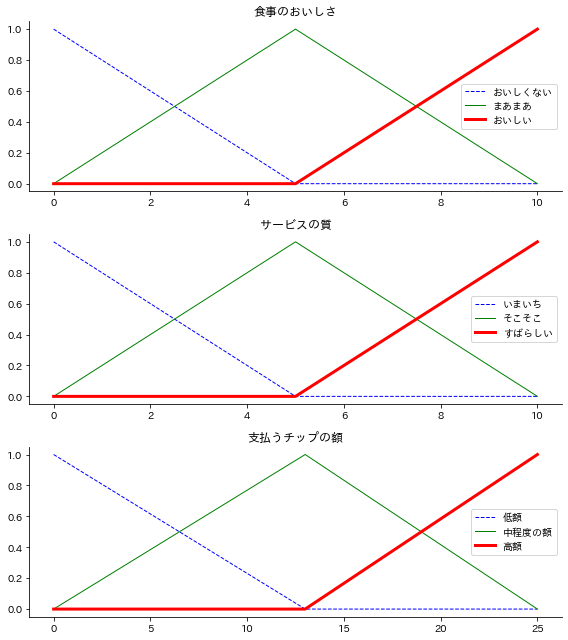

In [6]:
#3つのグラフの設定
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(8, 9))
#食事のおいしさのメンバシップ関数
ax0.plot(x_qual, qual_lo, 'b', linewidth=1, linestyle="--", label='おいしくない')
ax0.plot(x_qual, qual_md, 'g', linewidth=1, linestyle="-", label='まあまあ')
ax0.plot(x_qual, qual_hi, 'r', linewidth=3, linestyle="-", label='おいしい')
ax0.set_title('食事のおいしさ')
ax0.legend()
#サービスの良さのメンバシップ関数
ax1.plot(x_serv, serv_lo, 'b', linewidth=1, linestyle="--", label='いまいち')
ax1.plot(x_serv, serv_md, 'g', linewidth=1, linestyle="-", label='そこそこ')
ax1.plot(x_serv, serv_hi, 'r', linewidth=3, linestyle="-", label='すばらしい')
ax1.set_title('サービスの質')
ax1.legend()
#支払うチップの額のメンバシップ関数
ax2.plot(x_tip, tip_lo, 'b', linewidth=1, linestyle="--", label='低額')
ax2.plot(x_tip, tip_md, 'g', linewidth=1, linestyle="-", label='中程度の額')
ax2.plot(x_tip, tip_hi, 'r', linewidth=3, linestyle="-", label='高額')
ax2.set_title('支払うチップの額')
ax2.legend()

#右と上の軸を削除
for ax in (ax0, ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

#食事のおいしさとサービスの良さの点数の設定

In [11]:
#食事のおいしさの点数
qual_score = 6.0
#サービスの良さの点数
serv_score = 9.0

#支払うチップの決定（ルールの記述＋ファジー推論）

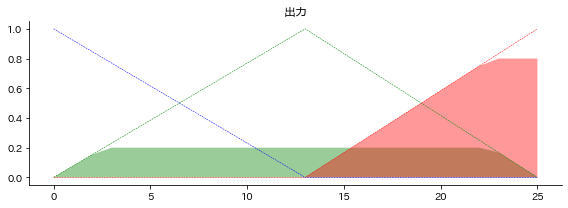

In [12]:
#食事のおいしさのグレードの計算
qual_level_lo = fuzz.interp_membership(x_qual, qual_lo, qual_score)
qual_level_md = fuzz.interp_membership(x_qual, qual_md, qual_score)
qual_level_hi = fuzz.interp_membership(x_qual, qual_hi, qual_score)

#サービスの良さのグレードの計算
serv_level_lo = fuzz.interp_membership(x_serv, serv_lo, serv_score)
serv_level_md = fuzz.interp_membership(x_serv, serv_md, serv_score)
serv_level_hi = fuzz.interp_membership(x_serv, serv_hi, serv_score)

#1つ目のルール
#食事がおいしくないのグレードとサービスがいまいちのグレードの大きい方を求める
active_rule1 = np.fmax(qual_level_lo, serv_level_lo)
#そのグレードと低額のメンバシップ関数の小さい方の範囲を設定
tip_activation_lo = np.fmin(active_rule1, tip_lo) 

#2つ目のルール
#サービスがまあまあのグレードと中程度の額のメンバシップ関数の小さい方の範囲を設定
tip_activation_md = np.fmin(serv_level_md, tip_md)

#1つ目のルール
#食事がおいしいのグレードとサービスが素晴らしいのグレードの大きい方を求める
active_rule3 = np.fmax(qual_level_hi, serv_level_hi)
#そのグレードと高額のメンバシップ関数の小さい方の範囲を設定
tip_activation_hi = np.fmin(active_rule3, tip_hi)

#描画のために0の配列を作っておく
tip0 = np.zeros_like(x_tip)

#可視化
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.fill_between(x_tip, tip0, tip_activation_lo, facecolor='b', alpha=0.4)
ax0.plot(x_tip, tip_lo, 'b', linewidth=0.5, linestyle='--', )
ax0.fill_between(x_tip, tip0, tip_activation_md, facecolor='g', alpha=0.4)
ax0.plot(x_tip, tip_md, 'g', linewidth=0.5, linestyle='--')
ax0.fill_between(x_tip, tip0, tip_activation_hi, facecolor='r', alpha=0.4)
ax0.plot(x_tip, tip_hi, 'r', linewidth=0.5, linestyle='--')
ax0.set_title('出力')

#右と上の軸を削除
for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

#支払うチップの決定（非ファジー化）

支払うチップの額 16.815327793167125


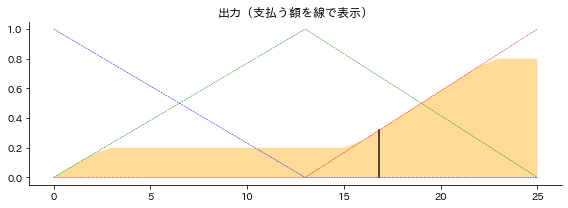

In [13]:
# すべての範囲を統合
aggregated = np.fmax(tip_activation_lo,
                     np.fmax(tip_activation_md, tip_activation_hi))

# 非ファジー化（支払う額の計算）
tip = fuzz.defuzz(x_tip, aggregated, 'centroid')
tip_activation = fuzz.interp_membership(x_tip, aggregated, tip)  # 描画用

print("支払うチップの額", tip)

#可視化
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.plot(x_tip, tip_lo, 'b', linewidth=0.5, linestyle='--', )
ax0.plot(x_tip, tip_md, 'g', linewidth=0.5, linestyle='--')
ax0.plot(x_tip, tip_hi, 'r', linewidth=0.5, linestyle='--')
ax0.fill_between(x_tip, tip0, aggregated, facecolor='Orange', alpha=0.4)
ax0.plot([tip, tip], [0, tip_activation], 'k', linewidth=1.5, alpha=0.9)
ax0.set_title('出力（支払う額を線で表示）')

#右と上の軸を削除
for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

#支払うチップの決定（ルールの記述＋ファジー推論＋非ファジー化）

支払うチップの額 14.566927763272412


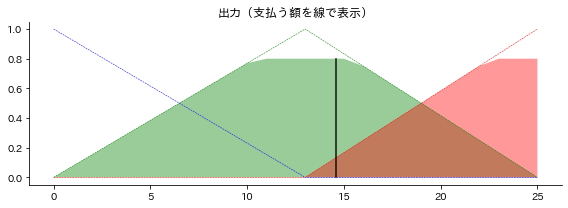

In [10]:
#食事のおいしさのグレードの計算
qual_level_lo = fuzz.interp_membership(x_qual, qual_lo, qual_score)
qual_level_md = fuzz.interp_membership(x_qual, qual_md, qual_score)
qual_level_hi = fuzz.interp_membership(x_qual, qual_hi, qual_score)

#サービスの良さのグレードの計算
serv_level_lo = fuzz.interp_membership(x_serv, serv_lo, serv_score)
serv_level_md = fuzz.interp_membership(x_serv, serv_md, serv_score)
serv_level_hi = fuzz.interp_membership(x_serv, serv_hi, serv_score)

#1つ目のルール
#食事がおいしくないのグレードとサービスがいまいちのグレードの大きい方を求める
active_rule1 = np.fmax(qual_level_lo, serv_level_lo)
#そのグレードと低額のメンバシップ関数の小さい方の範囲を設定
tip_activation_lo = np.fmin(active_rule1, tip_lo)  # removed entirely to 0

#2つ目のルール
#サービスがまあまあのグレードと中程度の額のメンバシップ関数の小さい方の範囲を設定
tip_activation_md = np.fmin(serv_level_md, tip_md)

#1つ目のルール
#食事がおいしいのグレードとサービスが素晴らしいのグレードの大きい方を求める
active_rule3 = np.fmax(qual_level_hi, serv_level_hi)
#そのグレードと高額のメンバシップ関数の小さい方の範囲を設定
tip_activation_hi = np.fmin(active_rule3, tip_hi)

# すべての範囲を統合
aggregated = np.fmax(tip_activation_lo,
                     np.fmax(tip_activation_md, tip_activation_hi))

# 非ファジー化（支払う額の計算）
tip = fuzz.defuzz(x_tip, aggregated, 'centroid')
tip_activation = fuzz.interp_membership(x_tip, aggregated, tip)  # for plot

print("支払うチップの額", tip)

#描画のために0の配列を作っておく
tip0 = np.zeros_like(x_tip)

#可視化
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.fill_between(x_tip, tip0, tip_activation_lo, facecolor='b', alpha=0.4)
ax0.plot(x_tip, tip_lo, 'b', linewidth=0.5, linestyle='--', )
ax0.fill_between(x_tip, tip0, tip_activation_md, facecolor='g', alpha=0.4)
ax0.plot(x_tip, tip_md, 'g', linewidth=0.5, linestyle='--')
ax0.fill_between(x_tip, tip0, tip_activation_hi, facecolor='r', alpha=0.4)
ax0.plot(x_tip, tip_hi, 'r', linewidth=0.5, linestyle='--')
ax0.plot([tip, tip], [0, tip_activation], 'k', linewidth=1.5, alpha=0.9)
ax0.set_title('出力（支払う額を線で表示）')

#右と上の軸を削除
for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()